In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel('CTG.xls',sheet_name=1)

In [2]:
df['Unnamed: 9'].isnull().sum()

2130

In [3]:
print(df.columns.tolist())

['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 22, 'Unnamed: 44', 23]


In [6]:
# Fix headers
df.columns = df.iloc[0]
df = df.iloc[1:]
df = df.reset_index(drop=True)

empty_cols = ['Unnamed: 9', 'Unnamed: 42', 'Unnamed: 44']

df = df.drop(columns=empty_cols, errors='ignore')

# Remove summary row
df = df.iloc[:-1]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (2127, 43)


In [7]:
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

X = df[feature_cols]
y = df['NSP']

In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_excel('CTG.xls',sheet_name='Raw Data')

In [18]:
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 
                'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']


In [19]:
def explore_dataset(df, feature_cols):
    """Perform initial exploration of the dataset"""
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"Features: {len(feature_cols)}")
    print(f"Samples: {df.shape[0]}")
    
    print("\n" + "=" * 60)
    print("MISSING VALUES")
    print("=" * 60)
    missing = df[feature_cols].isnull().sum()
    print(f"Total missing values: {missing.sum()}")
    if missing.sum() > 0:
        print(missing[missing > 0])
    
    print("\n" + "=" * 60)
    print("DATA TYPES")
    print("=" * 60)
    print(df[feature_cols].dtypes.value_counts())
    
    print("\n" + "=" * 60)
    print("BASIC STATISTICS")
    print("=" * 60)
    print(df[feature_cols].describe())
    
    return missing

explore_dataset(df, feature_cols)

DATASET OVERVIEW
Shape: (2130, 40)
Features: 21
Samples: 2130

MISSING VALUES
Total missing values: 72
LB          4
AC          4
FM          3
UC          3
DL          2
DS          2
DP          2
ASTV        3
MSTV        3
ALTV        3
MLTV        3
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
dtype: int64

DATA TYPES
float64    21
Name: count, dtype: int64

BASIC STATISTICS
                LB           AC           FM           UC           DL  \
count  2126.000000  2126.000000  2127.000000  2127.000000  2128.000000   
mean    133.303857     2.722484     7.503056     3.669017     1.576128   
std       9.840844     3.560850    39.030452     2.877148     2.517794   
min     106.000000     0.000000     0.000000     0.000000     0.000000   
25%     126.000000     0.000000     0.000000     1.000000     0.000000   
50%     133.000000     1.000000     0.000000     3.000000     0.000000   
75

LB          4
AC          4
FM          3
UC          3
DL          2
DS          2
DP          2
ASTV        3
MSTV        3
ALTV        3
MLTV        3
Width       4
Min         4
Max         4
Nmax        4
Nzeros      4
Mode        4
Mean        4
Median      4
Variance    4
Tendency    4
dtype: int64

In [20]:
# Drop empty rows and columns
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')

# Check duplicates
print("Duplicates:", df.duplicated().sum())

# Target variable
y = df['NSP']

# Features
X = df[feature_cols]

Duplicates: 0


In [21]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

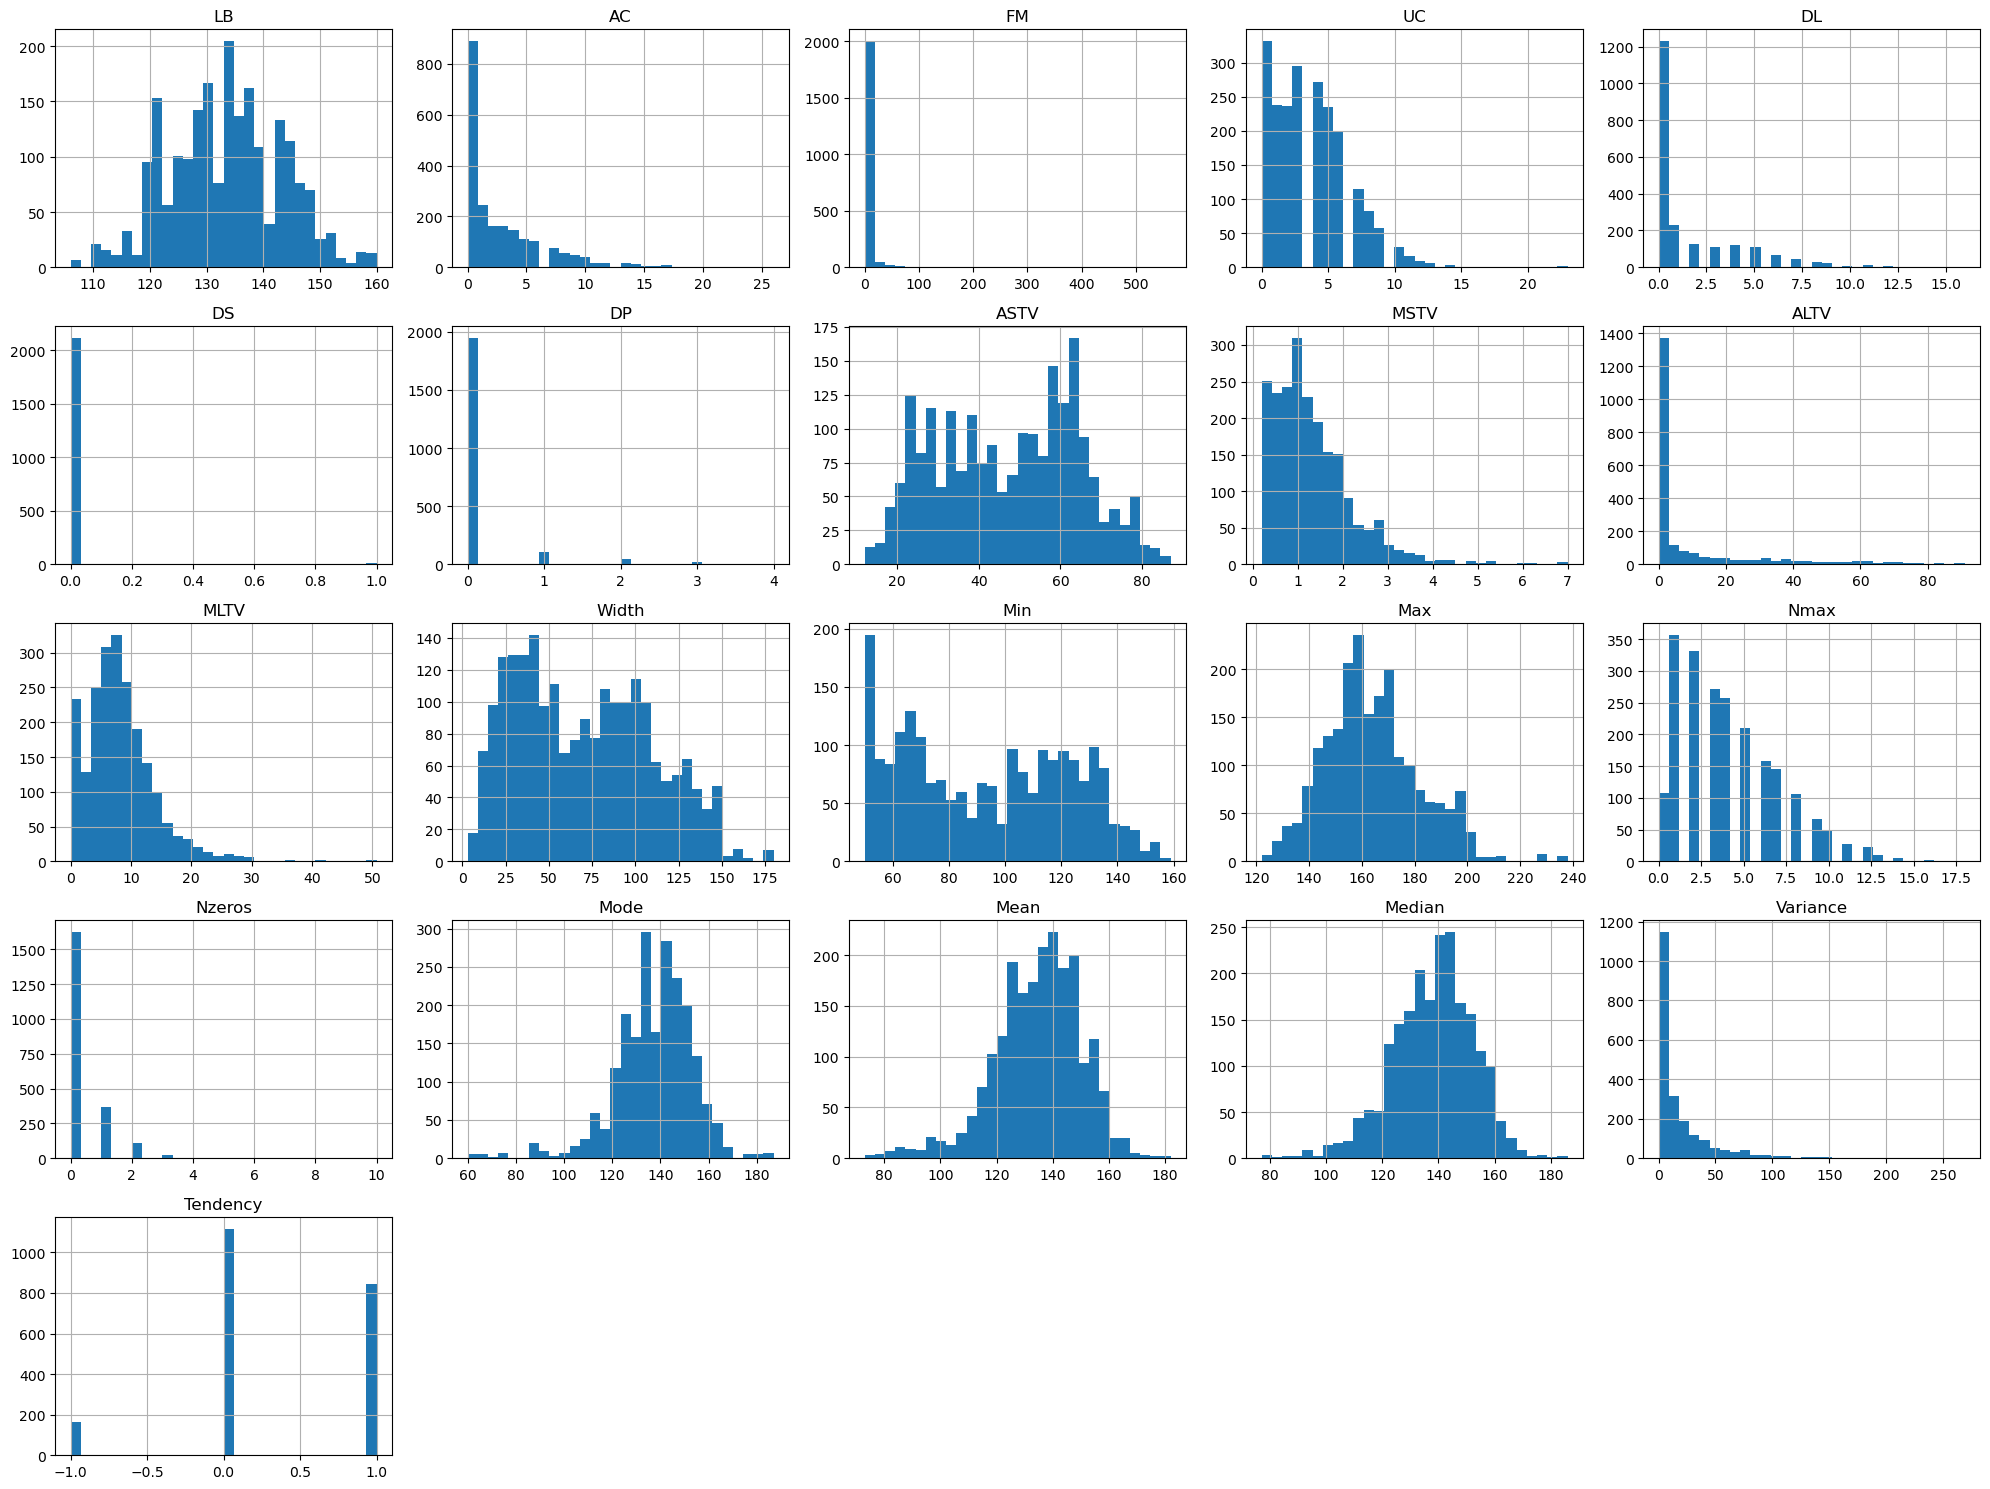

In [23]:
import matplotlib.pyplot as plt

X_imputed.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

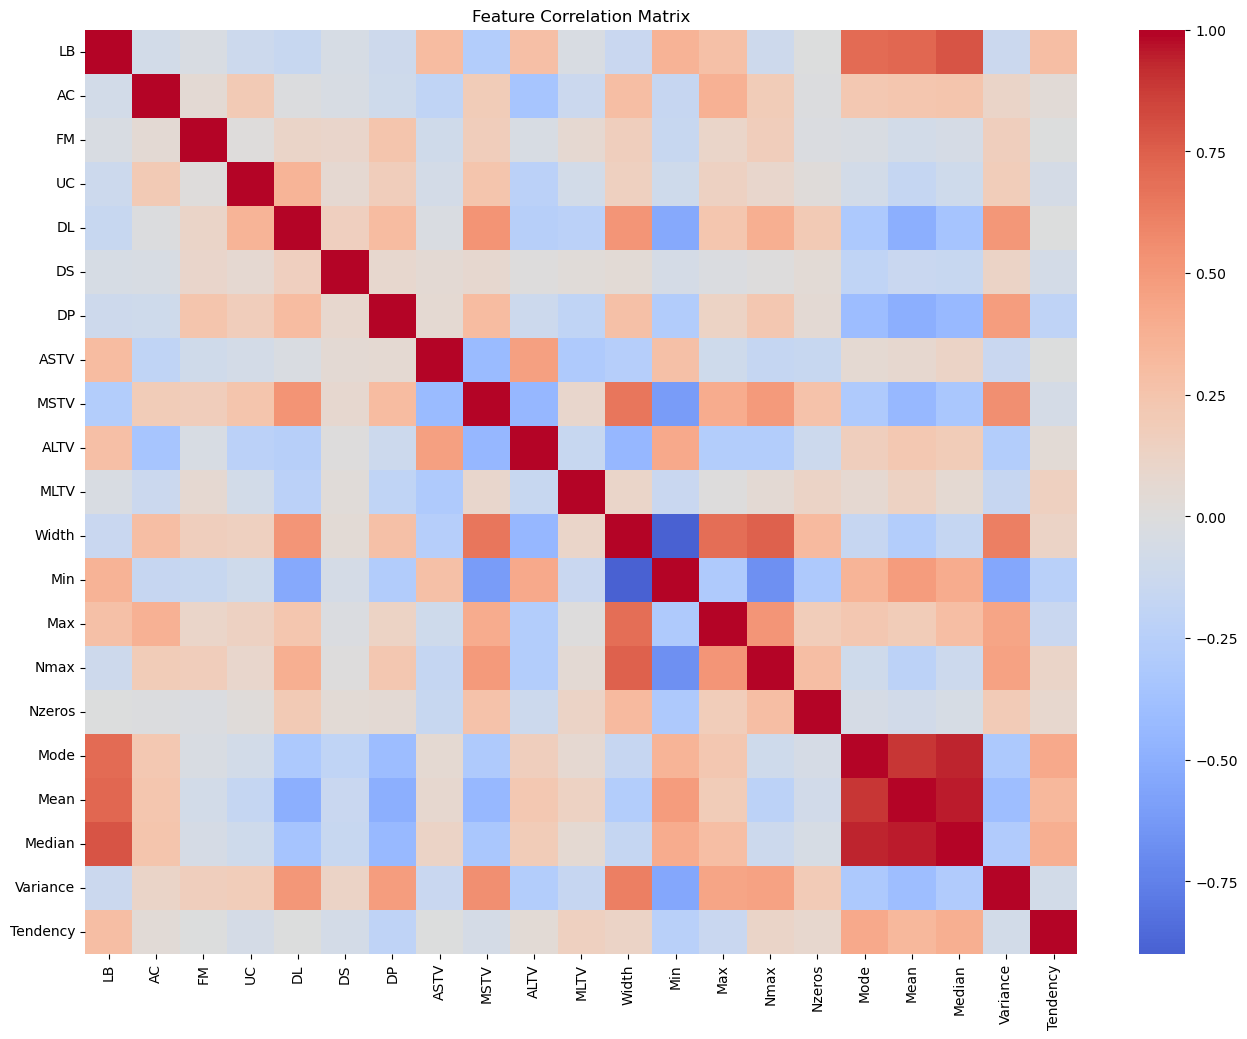

In [24]:
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(X_imputed.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [29]:
import numpy as np
from scipy import stats

# Your CTG feature columns
feature_cols = ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 
                'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 
                'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 
                'Mean', 'Median', 'Variance', 'Tendency']
print("hello");

def detect_skewness(df, feature_cols):
    """Calculate skewness for all features"""
    
    skew_results = []
    
    for col in feature_cols:
        data = df[col].dropna()
        skew_val = data.skew()  
        skew_test = stats.skewtest(data) 
        
        # Interpret skewness magnitude
        if abs(skew_val) < 0.5:
            interpretation = "Approximately symmetric"
        elif abs(skew_val) < 1:
            interpretation = "Moderately skewed"
        else:
            interpretation = "Highly skewed"
        # Direction
        direction = "Right-skewed (positive)" if skew_val > 0 else "Left-skewed (negative)"
        
        skew_results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Direction': direction,
            'Interpretation': interpretation,
            'P-value': skew_test.pvalue,
            'Significant': skew_test.pvalue < 0.05
        })
    
    # Create DataFrame
    skew_df = pd.DataFrame(skew_results)
    skew_df = skew_df.sort_values('Skewness', key=abs, ascending=False)
    
    print("=" * 80)
    print("SKEWNESS ANALYSIS FOR CTG DATA")
    print("=" * 80)
    print(skew_df.to_string(index=False))
    
    return skew_df

skewness_df = detect_skewness(df, feature_cols)

hello
SKEWNESS ANALYSIS FOR CTG DATA
 Feature  Skewness               Direction          Interpretation       P-value  Significant
      DS 16.228833 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      FM  9.455892 Right-skewed (positive)           Highly skewed  0.000000e+00         True
      DP  4.287248 Right-skewed (positive)           Highly skewed 4.517855e-292         True
  Nzeros  3.920287 Right-skewed (positive)           Highly skewed 1.277443e-270         True
Variance  3.219974 Right-skewed (positive)           Highly skewed 3.954336e-227         True
    ALTV  2.199481 Right-skewed (positive)           Highly skewed 3.397124e-155         True
      DL  1.858766 Right-skewed (positive)           Highly skewed 1.287967e-128         True
    MSTV  1.722670 Right-skewed (positive)           Highly skewed 1.464010e-117         True
      AC  1.658830 Right-skewed (positive)           Highly skewed 2.751932e-112         True
    MLTV  1.465029 Righ

In [30]:
from sklearn.impute import SimpleImputer
 
# Select only numeric columns
X_numeric = X.select_dtypes(include=['number']) 

# Impute missing values
imputer = SimpleImputer(strategy='median')

X_imputed_numeric = pd.DataFrame(
    imputer.fit_transform(X_numeric),
    columns=X_numeric.columns,
    index=X_numeric.index  
)

# Replace the numeric columns in original X
X_final = X.copy()
X_final[X_imputed_numeric.columns] = X_imputed_numeric

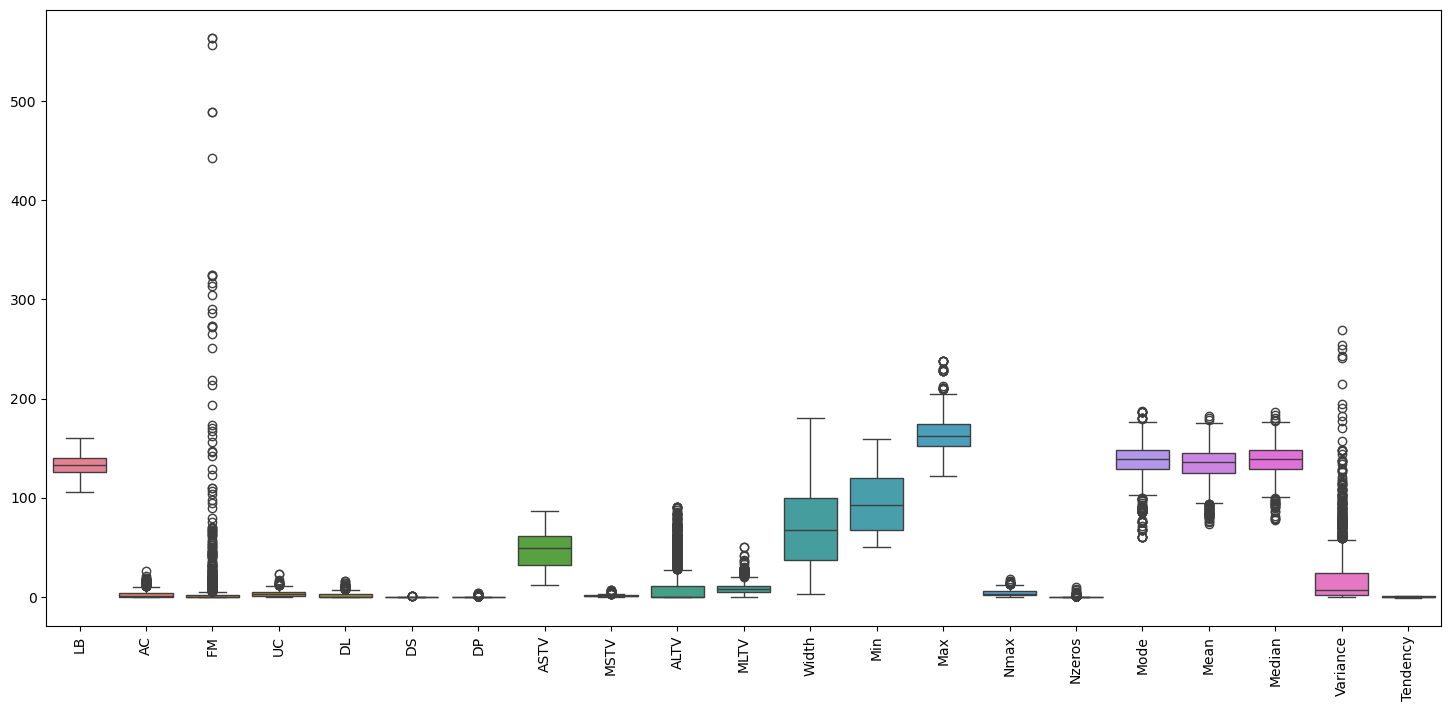

In [31]:
plt.figure(figsize=(18, 8))
sns.boxplot(data=X_imputed_numeric)
plt.xticks(rotation=90)
plt.show()